In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from skimage.metrics import structural_similarity
import os

In [2]:
img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Изображение не найдено!")
else:
    _, monoImg = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

    with open('mono.txt', 'w') as file:
        for row in monoImg:
            file.write(' '.join(str(pixel) for pixel in row) + '\n')

In [3]:
def wavelet_haar(data):
    data = data.astype(np.float32)
    rows, cols = data.shape

    horizontal = np.zeros_like(data)
    for r in range(rows):
        for c in range(0, cols - 1, 2):
            a = (data[r, c] + data[r, c+1]) / 2
            d = (data[r, c] - data[r, c+1]) / 2
            horizontal[r, c//2] = a
            horizontal[r, c//2 + cols//2] = d

        if cols % 2 == 1:
            horizontal[r, cols//2] = data[r, -1]

    vertical = np.zeros_like(horizontal)
    for c in range(cols):
        for r in range(0, rows - 1, 2):
            a = (horizontal[r, c] + horizontal[r+1, c]) / 2
            d = (horizontal[r, c] - horizontal[r+1, c]) / 2
            vertical[r//2, c] = a
            vertical[r//2 + rows//2, c] = d

        if rows % 2 == 1:
            vertical[rows//2, c] = horizontal[-1, c]

    half_r, half_c = rows // 2, cols // 2

    return (vertical[:half_r, :half_c],     # LL
            vertical[:half_r, half_c:],     # LH
            vertical[half_r:, :half_c],     # HL
            vertical[half_r:, half_c:],     # HH
            vertical)                       # full transform


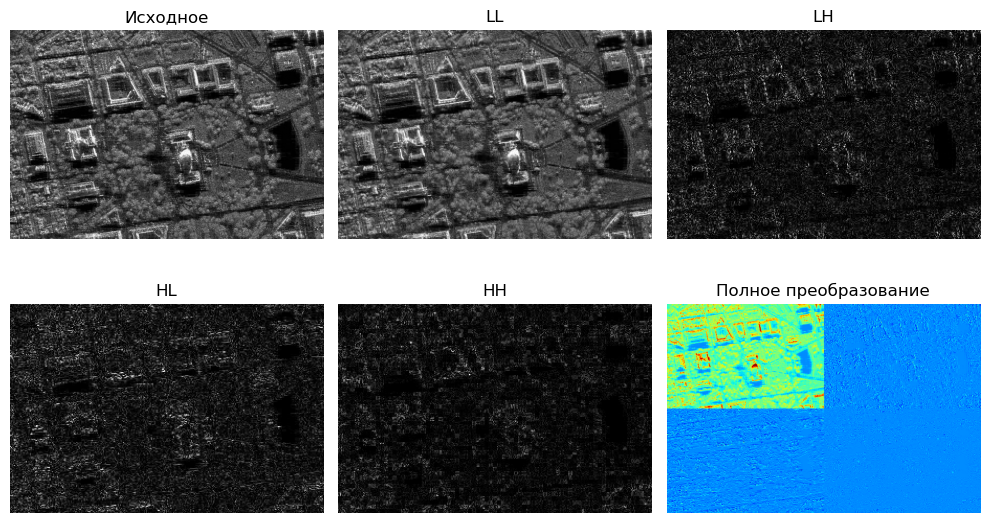

In [4]:
LL, LH, HL, HH, full_transform = wavelet_haar(img)

plt.figure(figsize=(10, 6))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title('Исходное')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(LL, cmap='gray')
plt.title('LL')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(np.abs(LH), cmap='gray')
plt.title('LH')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(HL), cmap='gray')
plt.title('HL')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(np.abs(HH), cmap='gray')
plt.title('HH')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(full_transform, cmap='jet')
plt.title('Полное преобразование')
plt.axis('off')

plt.tight_layout()
plt.show()


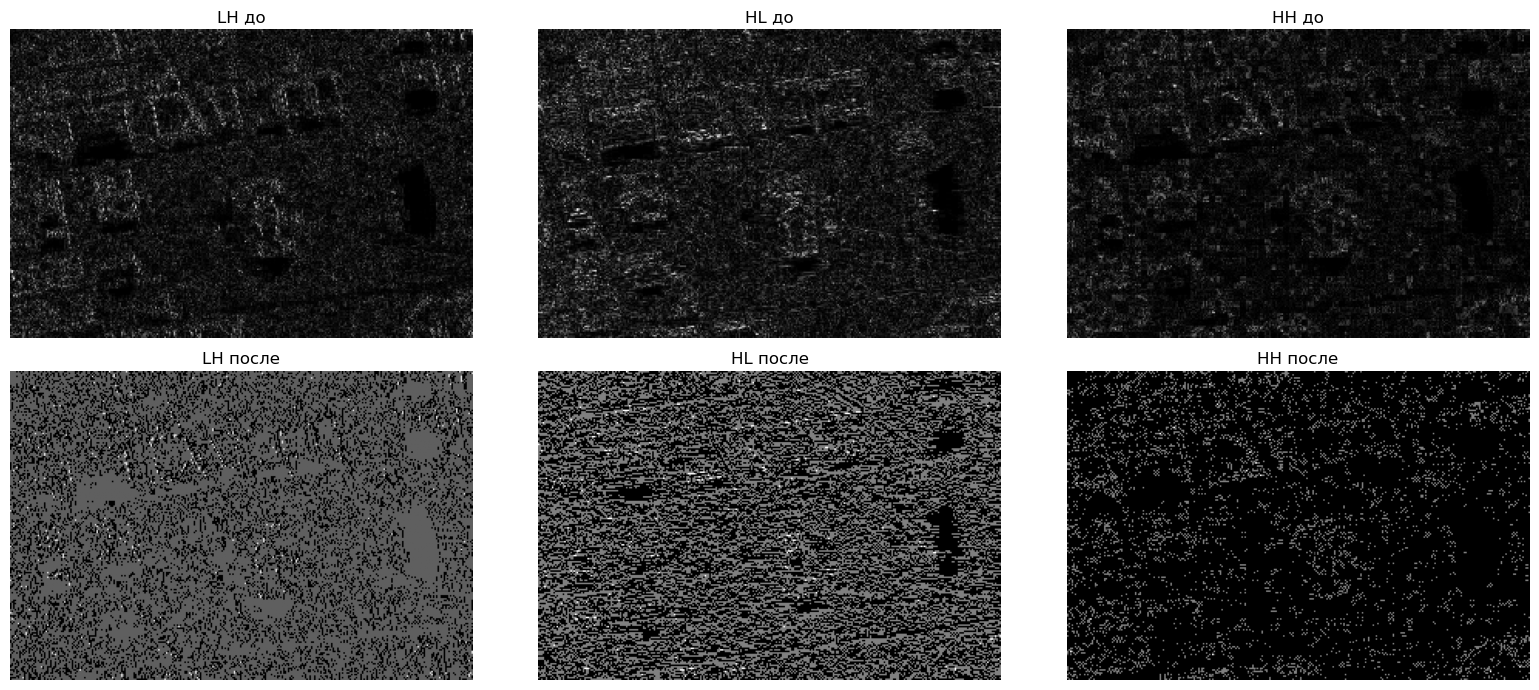

In [5]:
def quantize_data(comp, levels):
    min_val = comp.min()
    max_val = comp.max()
    step = (max_val - min_val) / levels
    q = np.floor((comp - min_val) / step).astype(int)
    return q, min_val, step

def dequantize_data(q, min_val, step):
    return min_val + q * step

levels = 4
LH_q, lh_min, lh_step = quantize_data(LH, levels)
HL_q, hl_min, hl_step = quantize_data(HL, levels)
HH_q, hh_min, hh_step = quantize_data(HH, levels)

LH_r = dequantize_data(LH_q, lh_min, lh_step)
HL_r = dequantize_data(HL_q, hl_min, hl_step)
HH_r = dequantize_data(HH_q, hh_min, hh_step)

plt.figure(figsize=(16, 7))
titles = ["LH до", "HL до", "HH до", "LH после", "HL после", "HH после"]
images = [LH, HL, HH, LH_r, HL_r, HH_r]

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(np.abs(images[i]), cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [6]:

from collections import Counter

def encode_pairs(component):
    counts = Counter(component.flatten())
    return list(counts.items())  

LH_pairs = encode_pairs(LH_q)
HL_pairs = encode_pairs(HL_q)
HH_pairs = encode_pairs(HH_q)

with open("haar.txt", "w") as file:

    np.savetxt(file, LL, fmt="%.2f")
    file.write("\n")

   
    for name, pairs in [("LH", LH_pairs), ("HL", HL_pairs), ("HH", HH_pairs)]:
        file.write(f"# {name} component\n")
        for value, count in pairs:
            file.write(f"{value} {count}\n")
        file.write("\n")

print("Сохранено в haar")


Сохранено в haar


In [7]:

o_size = os.path.getsize("mono.txt")
h_size = os.path.getsize("haar.txt")

print(f"Размер исходного файла: {o_size} байт")
print(f"Размер после Хаара: {h_size} байт")
print(f"Коэффициент сжатия: {o_size / h_size:.2f} раз")


Размер исходного файла: 528942 байт
Размер после Хаара: 371152 байт
Коэффициент сжатия: 1.43 раз
